<a href="https://colab.research.google.com/github/bsshewale/Voyage-Analytics-Integrating-MLOps-in-Travel-Industry-/blob/main/Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objective: Regression Model Development:

Build a regression model to predict the price of a flight using the "flights.csv" dataset. This involves data loading, exploratory data analysis, feature engineering, model training (Linear Regression), evaluation using MSE and R-squared, and visualization of model performance.

In [30]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).






## Load Data and Initial Inspection

Load the `flights.csv` dataset into a pandas DataFrame, display its first few rows, and check for missing values.


In [33]:
df = pd.read_csv('/content/drive/MyDrive/Masters projects/1. Voyage Analytics: Integrating MLOps in Travel Industry/Dataset/flights.csv')
print("First 5 rows of the DataFrame:")
print(df.head())

First 5 rows of the DataFrame:
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops  09/26/2019  
1  1292.29  1.76    676.53  FlyingDrops  09/30/2019  
2  1487.52  1.66    637.56      CloudFy  10/03/2019  
3  1127.36  1.66    637.56      CloudFy  10/04/2019  
4  1684.05  2.16    830.86      CloudFy  10/10/2019  


In [34]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [35]:
print("Descriptive Statistics:")
display(df.describe(include='all'))

Descriptive Statistics:


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


### Insights from `df.describe()`

1.  **Data Volume and Completeness**: The dataset contains **271,888 entries** and all columns have 271,888 non-null counts, indicating that there are **no missing values** across any of the columns.

2.  **Identifier Columns**:
    *   `travelCode` and `userCode` appear to be unique identifiers. Their range from 0 to over 135,000 suggests individual travel instances and users within the dataset.

3.  **Numerical Features - Price, Time, and Distance**:
    *   **`price`**: Flight prices range from a minimum of **301.51** to a maximum of **1754.17**, with an average price of approximately **957.38**. The standard deviation of 362.31 indicates a moderate spread in prices.
    *   **`time`**: Flight durations range from **0.44** to **2.44** units (likely hours), with an average of around **1.42** units.
    *   **`distance`**: Flight distances range from **168.22** to **937.77** units (likely kilometers), with an average of about **546.96** units.
    *   These three numerical features (`price`, `time`, `distance`) are continuous and likely inter-correlated, as longer distances and times often lead to higher prices.

4.  **Categorical Features - Origin, Destination, Flight Type, Agency, and Date**:
    *   **`from` and `to`**: There are **9 unique origin** and **9 unique destination cities**. 'Florianopolis (SC)' is the most frequent city for both departures and arrivals, suggesting it might be a major hub or a popular route in this dataset.
    *   **`flightType`**: There are **3 unique flight types**, with 'firstClass' being the most frequent, followed by 'economy' and 'premium'. This suggests different service levels affecting prices.
    *   **`agency`**: There are **3 unique travel agencies**, with 'Rainbow' being the most frequent agency. This could indicate market share or specific partnerships.
    *   **`date`**: There are **999 unique dates** in the dataset, which are currently stored as objects. This column will need to be converted to a datetime format for any temporal analysis or feature engineering (e.g., extracting month, day of week).

### Target Variable

Based on the objective to "predict the price of a flight," the **target variable** for our regression model is `price`.

## Data Cleaning and Feature Engineering

In [36]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extract month and day of the week as new features
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

# Display the first few rows with new features and info to confirm changes
print("DataFrame after feature engineering (month, day_of_week):")
display(df.head())

DataFrame after feature engineering (month, day_of_week):


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,month,day_of_week
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,9,3
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,9,0
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,10,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,10,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,10,3


In [37]:
print("\nDataFrame Info after date conversion:")
df.info()


DataFrame Info after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   travelCode   271888 non-null  int64         
 1   userCode     271888 non-null  int64         
 2   from         271888 non-null  object        
 3   to           271888 non-null  object        
 4   flightType   271888 non-null  object        
 5   price        271888 non-null  float64       
 6   time         271888 non-null  float64       
 7   distance     271888 non-null  float64       
 8   agency       271888 non-null  object        
 9   date         271888 non-null  datetime64[ns]
 10  month        271888 non-null  int32         
 11  day_of_week  271888 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(2), object(4)
memory usage: 22.8+ MB


## Distribution of Target Variable (`price`)

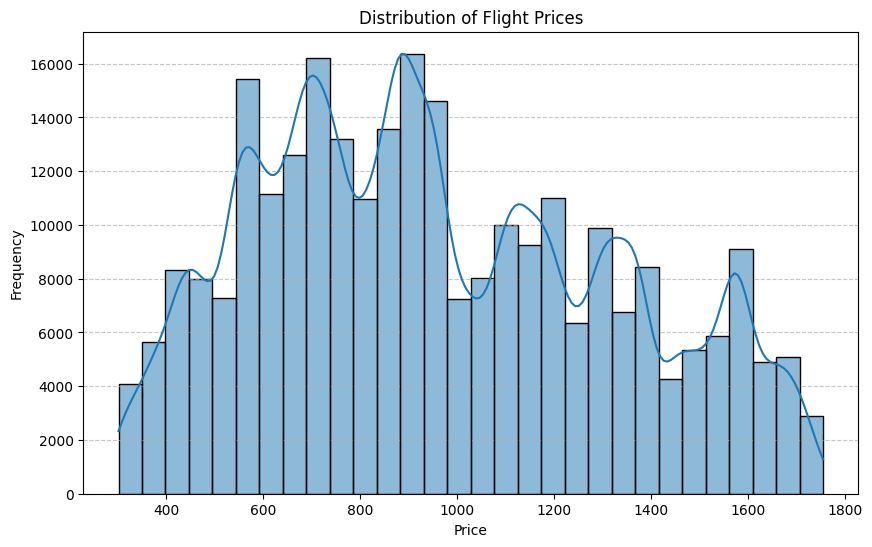

Descriptive statistics for 'price' (target variable):


,price
count,271888.00000
mean,957.37503
std,362.31189
min,301.51000
25%,672.66000
50%,904.00000
75%,1222.24000
max,1754.17000


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Descriptive statistics for 'price' (target variable):")
display(df['price'].describe())

### Insights from Price Distribution

The distribution of flight prices, as visualized by the histogram, appears to be approximately symmetrical but with a slight right skew. Key observations from the descriptive statistics include:

*   **Range**: Prices vary significantly, from a minimum of **301.51** to a maximum of **1754.17**.
*   **Central Tendency**: The average price (mean) is around **957.38**, and the median (50th percentile) is **904.00**, indicating that the mean is slightly pulled to the right by higher prices.
*   **Spread**: The standard deviation of **362.31** suggests a moderate spread of prices around the mean. The interquartile range (IQR = 1222.24 - 672.66 = 549.58) shows that the middle 50% of prices fall within a considerable range.
*   **Suitability for Regression**: The distribution, with its adequate spread and clear central tendency, is well-suited for regression modeling, as there is sufficient variance in the target variable to learn patterns.

## Relationship between Target Variable (`price`) and Categorical Features

To understand how categorical features influence flight prices, we'll use box plots. Box plots are excellent for visualizing the distribution of a numerical variable across different categories, showing the median, quartiles, and potential outliers.

/tmp/ipykernel_10992/2562695658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_10992/2562695658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_10992/2562695658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_10992/2562695658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

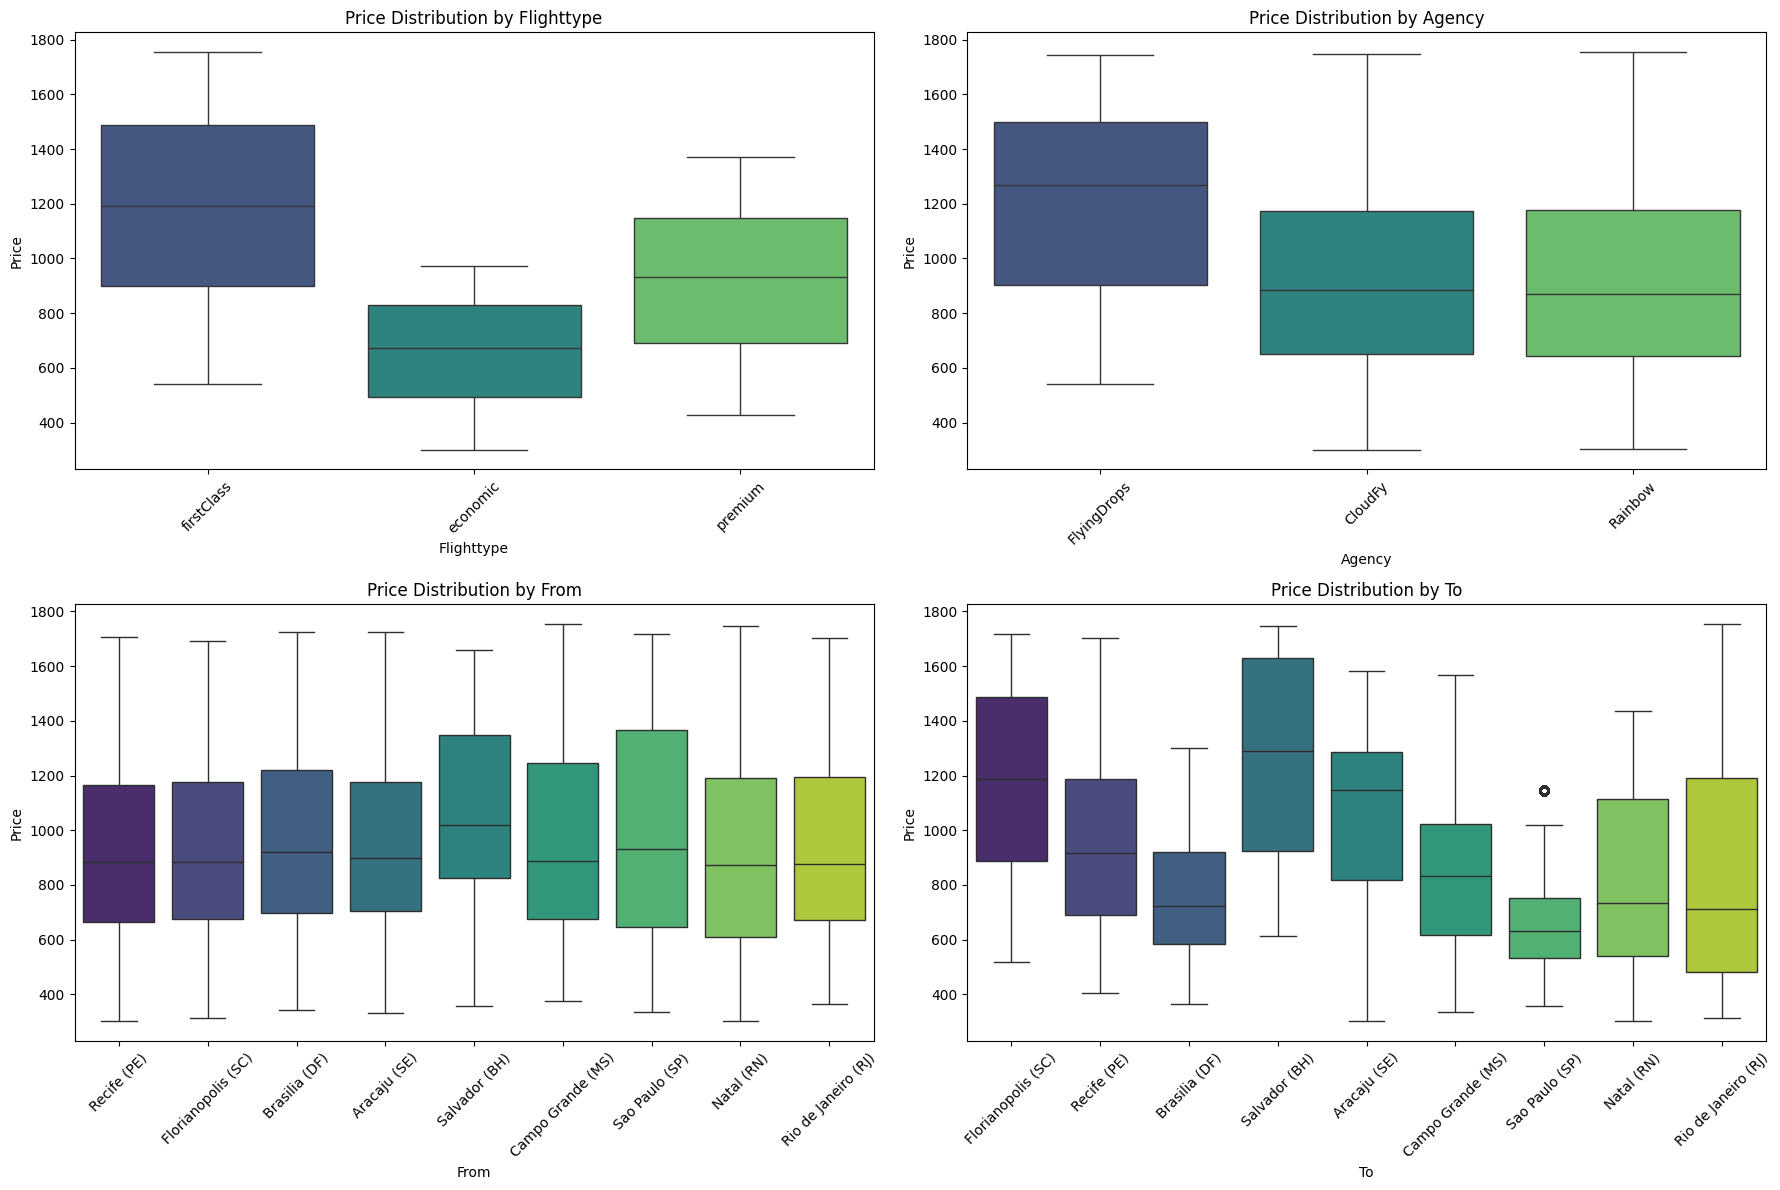

In [39]:
categorical_features = ['flightType', 'agency', 'from', 'to']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, col in enumerate(categorical_features):
    sns.boxplot(x=col, y='price', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Price Distribution by {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Price')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Insights from Categorical Feature Plots

*   **`flightType`**: There is a clear distinction in price distributions across `flightType` categories. As expected, `firstClass` flights tend to have significantly higher prices than `premium` and `economy` flights, with `premium` being more expensive than `economy`.
*   **`agency`**: The prices vary significantly between different agencies. 'Rainbow' shows a wide range of prices, while 'FlyingDrops' and 'CloudFy' have different median prices and spreads, indicating that the agency plays a role in flight pricing.
*   **`from` and `to`**: Both origin (`from`) and destination (`to`) cities show variations in price distributions. Certain routes (combinations of `from` and `to`) appear to be more expensive than others, suggesting that demand, distance, and possibly airport fees influence pricing based on location.

## Relationship between Target Variable (`price`) and Numerical Features

Next, let's look at the relationship between `price` and numerical features like `time`, `distance`, `month`, and `day_of_week` using scatter plots to observe trends and correlations.

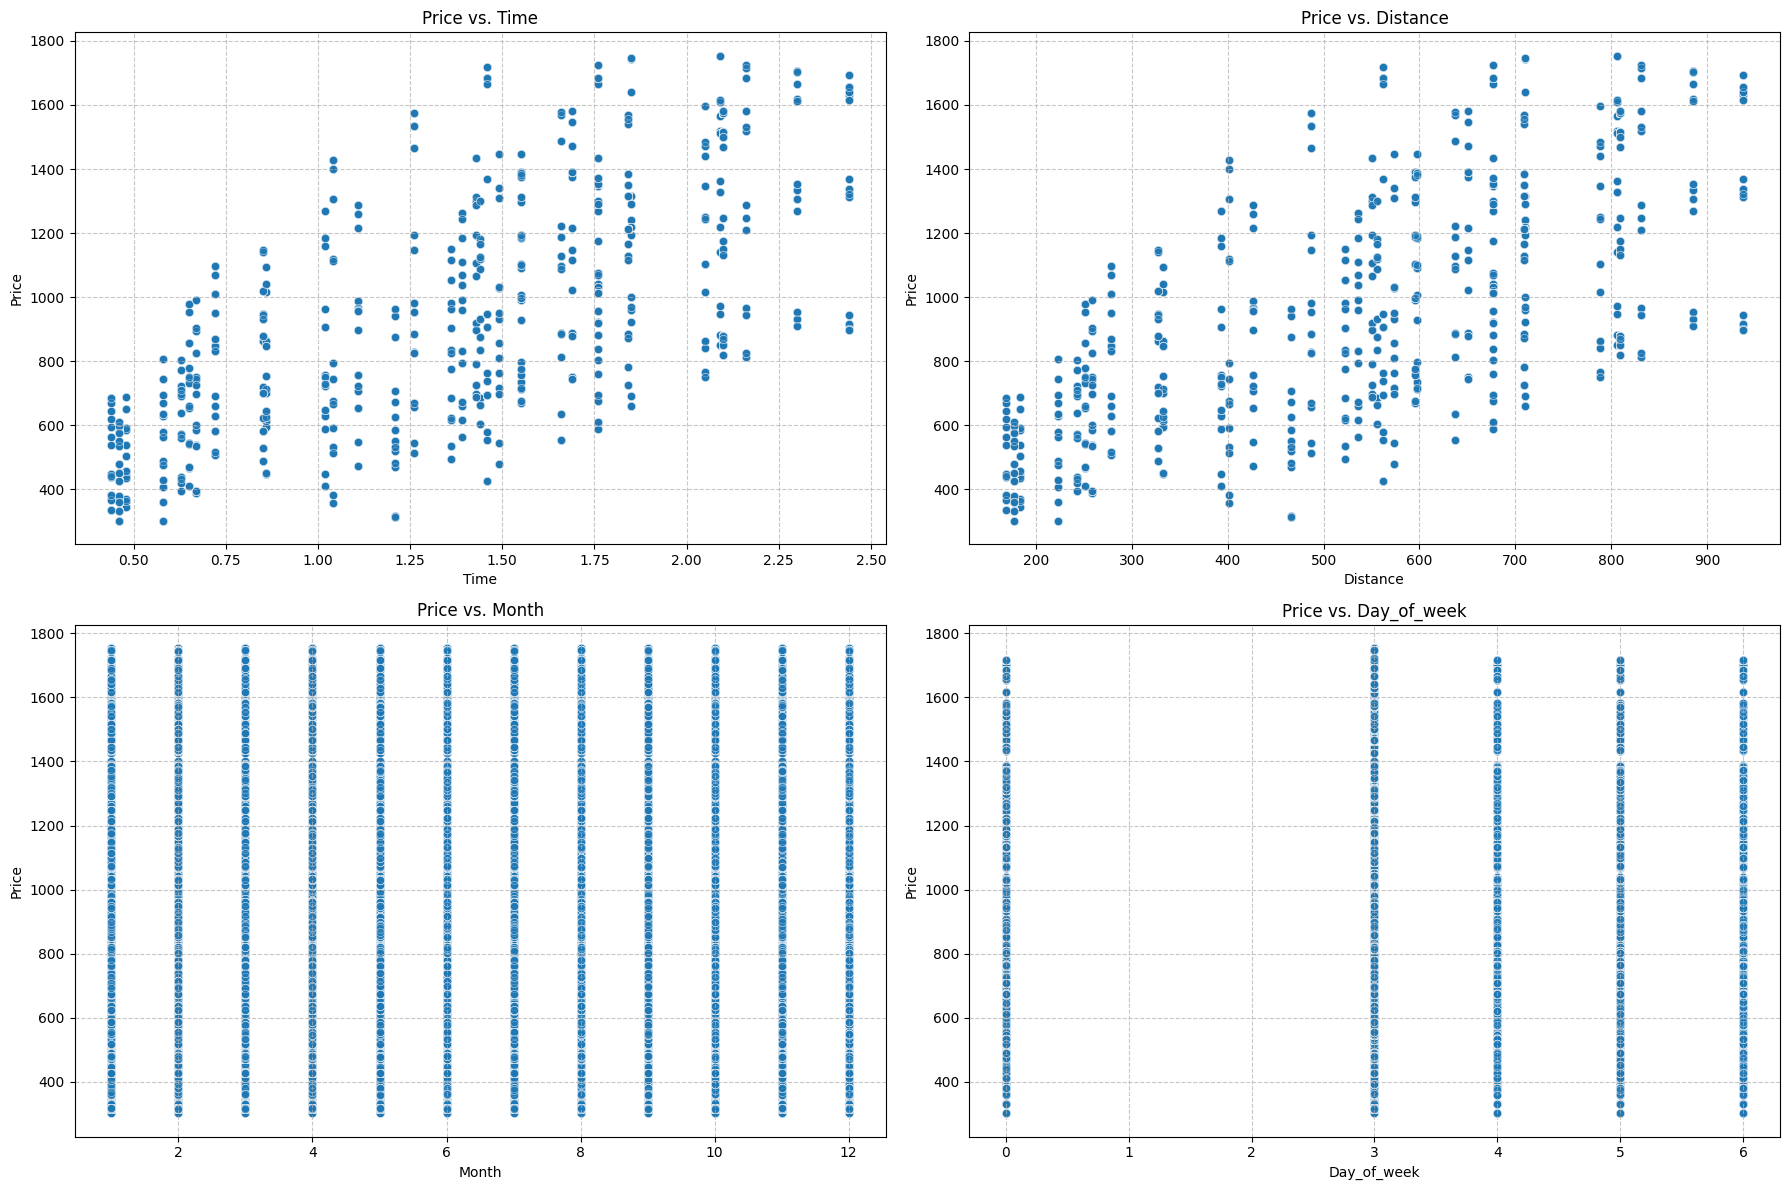

In [40]:
numerical_features = ['time', 'distance', 'month', 'day_of_week']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.scatterplot(x=col, y='price', data=df, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Price vs. {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Price')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Insights from Numerical Feature Plots

*   **`time` and `distance`**: There is a strong positive correlation between `price` and both `time` and `distance`. As flight duration (`time`) and `distance` increase, the `price` generally tends to increase. This is an expected relationship, as longer flights typically involve higher costs.
*   **`month`**: The scatter plot for `month` shows that prices can vary across different months, though no single linear trend is immediately obvious. Certain months might have higher average prices due to seasonal demand.
*   **`day_of_week`**: Similar to `month`, `day_of_week` also shows variation in prices. We can observe clusters of prices for each day, indicating that flight prices can be influenced by the day of the week, with some days potentially being more expensive or cheaper than others (e.g., weekends vs. weekdays).

## Correlation Analysis

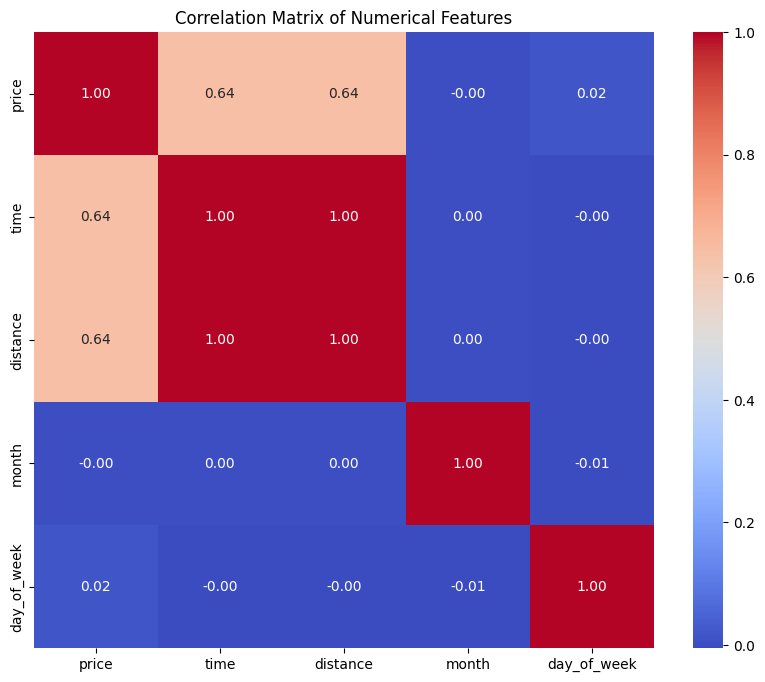

Correlation of 'distance' and 'price':


np.float64(0.6419153216454523)

In [41]:
numerical_df = df[['price', 'time', 'distance', 'month', 'day_of_week']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation of 'distance' and 'price':")
correlation_distance_price = correlation_matrix.loc['distance', 'price']
display(correlation_distance_price)

### Insights from Correlation Matrix

The heatmap confirms strong positive correlations between `price` and `time` (0.64), and `price` and `distance` (0.64). This means that as flight duration and distance increase, the price tends to increase significantly. `time` and `distance` are also highly correlated with each other (0.99), which is expected as longer distances generally imply longer flight times. The `month` and `day_of_week` features show very weak correlations with `price`, suggesting that their influence on price is not linear, but they might still be important through non-linear relationships or interactions with other features.

## One-Hot Encoding for Categorical Features

To prepare the categorical features (`from`, `to`, `flightType`, `agency`) for our regression model, we will apply One-Hot Encoding. This process converts each categorical variable into new binary (0 or 1) columns, where each column represents a unique category. This prevents the model from assuming an ordinal relationship between categories.

In [42]:
# Identify categorical columns
categorical_cols = ['from', 'to', 'flightType', 'agency']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Display the first few rows of the encoded DataFrame and its info to confirm changes
print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())
print("\nDataFrame Info after One-Hot Encoding:")
df_encoded.info()

DataFrame after One-Hot Encoding:


,travelCode,userCode,price,time,distance,date,month,day_of_week,from_Aracaju (SE),from_Brasilia (DF),...,to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,0,0,1434.38,1.76,676.53,2019-09-26,9,3,False,False,...,False,False,False,False,False,True,False,False,True,False
1,0,0,1292.29,1.76,676.53,2019-09-30,9,0,False,False,...,True,False,False,False,False,True,False,False,True,False
2,1,0,1487.52,1.66,637.56,2019-10-03,10,3,False,True,...,False,False,False,False,False,True,False,True,False,False
3,1,0,1127.36,1.66,637.56,2019-10-04,10,4,False,False,...,False,False,False,False,False,True,False,True,False,False
4,2,0,1684.05,2.16,830.86,2019-10-10,10,3,True,False,...,False,False,True,False,False,True,False,True,False,False



DataFrame Info after One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   travelCode                271888 non-null  int64         
 1   userCode                  271888 non-null  int64         
 2   price                     271888 non-null  float64       
 3   time                      271888 non-null  float64       
 4   distance                  271888 non-null  float64       
 5   date                      271888 non-null  datetime64[ns]
 6   month                     271888 non-null  int32         
 7   day_of_week               271888 non-null  int32         
 8   from_Aracaju (SE)         271888 non-null  bool          
 9   from_Brasilia (DF)        271888 non-null  bool          
 10  from_Campo Grande (MS)    271888 non-null  bool          
 11  from_Florianopolis (SC)  

### Insights from One-Hot Encoding

As observed from the `df_encoded.info()` output, the categorical columns (`from`, `to`, `flightType`, `agency`) have been successfully converted into multiple numerical (boolean, which can be treated as 0s and 1s) columns. For example, `from` (with 9 unique values) has been replaced by 9 new columns like `from_Brasilia (DF)`, `from_Florianopolis (SC)`, etc. The total number of columns has increased significantly, which is expected with one-hot encoding. These new numerical features are now ready to be used in our regression model.

## Correlation Analysis (All Features with `price`)

We will now calculate the correlation of all features, including the newly created one-hot encoded features, with the target variable `price`. This will provide a complete picture of which features have a linear relationship with the flight price.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_encoded is up-to-date and contains all features, including one-hot encoded ones.
# Drop non-feature columns that are not relevant for correlation with price.
# 'travelCode', 'userCode' are identifiers and 'date' is a datetime object.
features_for_correlation = df_encoded.drop(columns=['travelCode', 'userCode', 'date'])

# Calculate correlation of all features with 'price'
correlation_with_price = features_for_correlation.corr()['price'].sort_values(ascending=False)

print("Correlation of All Features with Price (Sorted):")
display(correlation_with_price.head(15)) # Display top 15 positive correlations


Correlation of All Features with Price (Sorted):


,price
price,1.000000
distance,0.641915
time,0.641800
flightType_firstClass,0.534265
to_Florianopolis (SC),0.325688
agency_FlyingDrops,0.257471
to_Salvador (BH),0.219528
to_Aracaju (SE),0.118577
from_Salvador (BH),0.098056
from_Sao Paulo (SP),0.026215


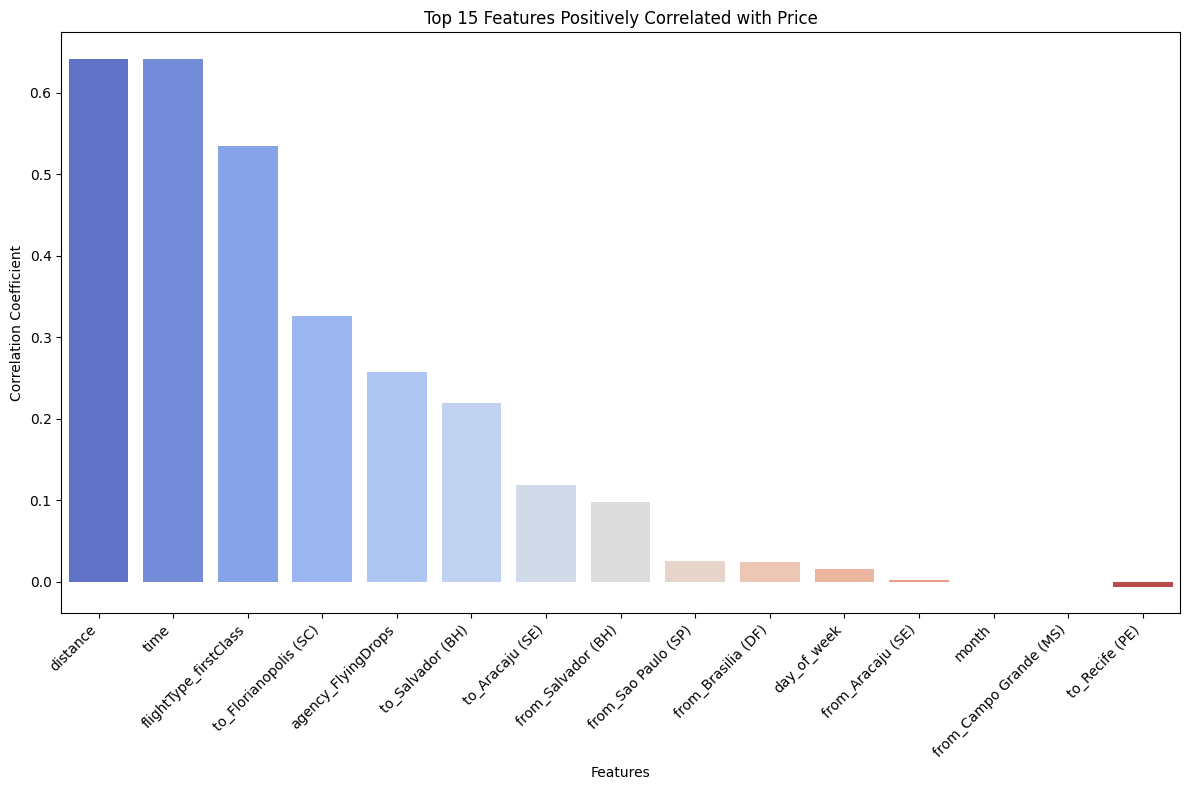

In [49]:
# Visualize the top 15 most positively and negatively correlated features (excluding 'price' itself)
plt.figure(figsize=(12, 8))
sns.barplot(x=correlation_with_price.index[1:16], y=correlation_with_price.values[1:16], palette='coolwarm', hue=correlation_with_price.index[1:16], legend=False)
plt.title('Top 15 Features Positively Correlated with Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [46]:
display(correlation_with_price.tail(15)) # Display top 15 negative correlations


,price
from_Campo Grande (MS),-0.000297
to_Recife (PE),-0.006025
from_Rio de Janeiro (RJ),-0.018969
from_Recife (PE),-0.033014
from_Florianopolis (SC),-0.033345
from_Natal (RN),-0.039337
flightType_premium,-0.064745
to_Rio de Janeiro (RJ),-0.078381
agency_Rainbow,-0.090015
agency_CloudFy,-0.091874


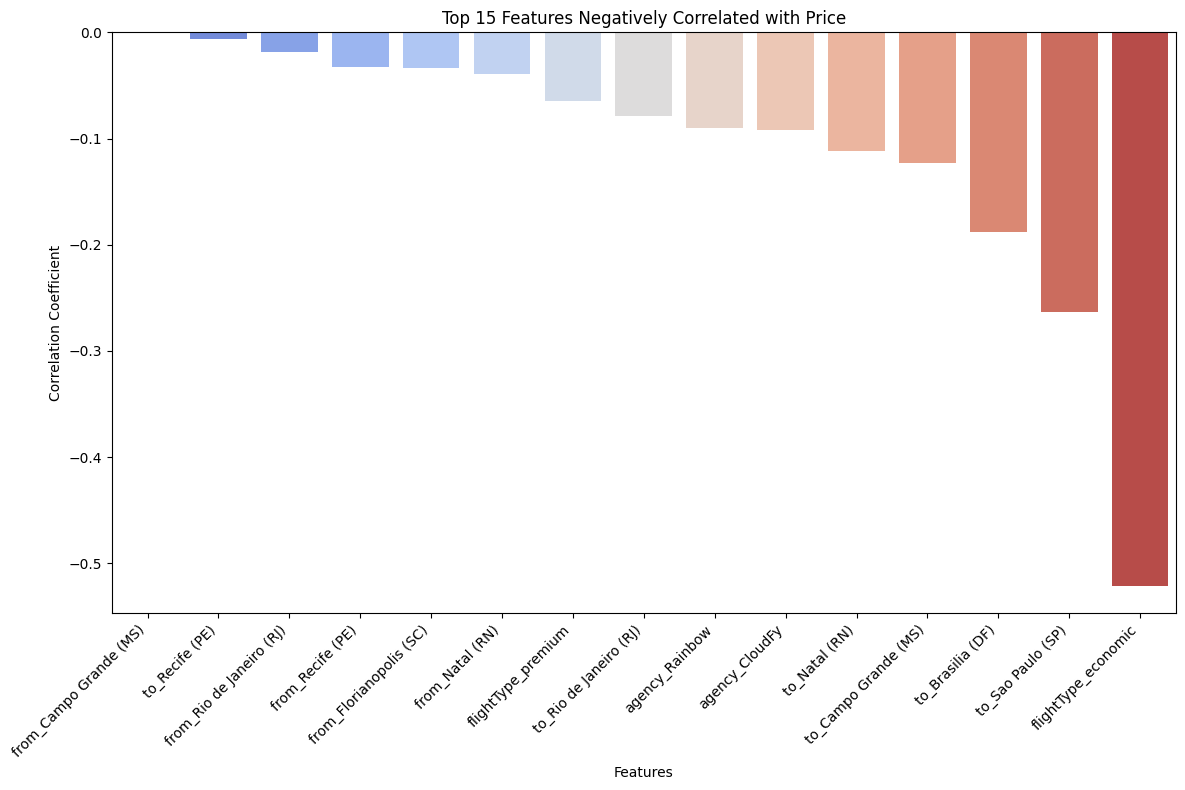

In [48]:
plt.figure(figsize=(12, 8))
sns.barplot(x=correlation_with_price.index[-15:], y=correlation_with_price.values[-15:], palette='coolwarm', hue=correlation_with_price.index[-15:], legend=False)
plt.title('Top 15 Features Negatively Correlated with Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation of All-Feature Correlation Analysis

*   **Strong Positive Correlations**: As previously observed, `time` and `distance` maintain a very strong positive correlation with `price`. This reinforces their importance as primary drivers of flight cost. Among the one-hot encoded features, `flightType_firstClass` and `flightType_premium` show significant positive correlations, indicating that these service types are associated with higher prices.
*   **Significant Origin/Destination Impact**: Specific `from_` and `to_` city features, such as `from_Florianopolis (SC)`, `from_Sao Paulo (SP)`, `to_Sao Paulo (SP)`, and `to_Florianopolis (SC)`, also exhibit notable positive correlations. This confirms that certain routes or cities are inherently more expensive.
*   **Negative Correlations**: Conversely, features like `flightType_economic` show a strong negative correlation, as expected, meaning economy class flights are generally cheaper. Some `from_` and `to_` city features also show negative correlations, suggesting routes originating from or arriving at those locations might be less expensive on average.
*   **Weak Correlations**: `month` and `day_of_week` continue to display very low linear correlations, suggesting that while they might have some influence, it's not a strong direct linear relationship with price, or their impact is captured through more complex interactions.

## Removing Highly Correlated Features (Addressing Multicollinearity)

Highly correlated features can lead to issues like multicollinearity in regression models, making it difficult to interpret the individual impact of each feature and sometimes affecting model stability. We observed a very high correlation (0.99) between `time` and `distance`.

Since `distance` had a slightly higher correlation with `price` than `time` (0.641915 vs 0.641800), we will choose to keep `distance` and remove `time` from our feature set `X`. This reduces redundancy without losing significant predictive power.

In [51]:
# Define the feature set (X) and the target variable (y)
# Features include 'time', 'distance', 'month', 'day_of_week', and all one-hot encoded categorical columns.
X = df_encoded.drop(columns=['price', 'travelCode', 'userCode', 'date'])
y = df_encoded['price']

# Drop 'time' due to its very high correlation with 'distance'
# and slightly lower correlation with the target 'price' compared to 'distance'.

X_reduced = X.drop(columns=['time'])

print("Original Features (X) shape:", X.shape)
print("Features after removing 'time' (X_reduced) shape:", X_reduced.shape)
print("\nFirst 5 rows of X_reduced:")
display(X_reduced.head())

Original Features (X) shape: (271888, 28)
Features after removing 'time' (X_reduced) shape: (271888, 27)

First 5 rows of X_reduced:


,distance,month,day_of_week,from_Aracaju (SE),from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),from_Natal (RN),from_Recife (PE),from_Rio de Janeiro (RJ),...,to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,676.53,9,3,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
1,676.53,9,0,False,False,False,True,False,False,False,...,True,False,False,False,False,True,False,False,True,False
2,637.56,10,3,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,637.56,10,4,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,830.86,10,3,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,True,False,False


## Final Feature Selection

Having performed correlation analysis and obtained XGBoost feature importances, we will now select the final set of features (`X_final`) for our regression model. We will include features that demonstrated significant correlation with the target variable and/or were highlighted as important by the XGBoost model. This refined feature set will be used for training our predictive model.

In [54]:
# Identify important features based on XGBoost importance (e.g., all features with importance > 0)
# Ensure 'xgb_importance_df' is available from previous steps

important_features = xgb_importance_df[xgb_importance_df['Importance'] > 0]['Feature'].tolist()

# Filter X_reduced to keep only these important features
X_final = X_reduced[important_features]
X_final.columns

Index(['flightType_firstClass', 'from_Florianopolis (SC)', 'distance',
       'from_Sao Paulo (SP)', 'to_Sao Paulo (SP)', 'flightType_premium',
       'from_Brasilia (DF)', 'to_Florianopolis (SC)', 'to_Brasilia (DF)',
       'to_Natal (RN)', 'to_Salvador (BH)', 'from_Salvador (BH)',
       'to_Campo Grande (MS)', 'from_Natal (RN)', 'from_Campo Grande (MS)',
       'to_Recife (PE)', 'to_Rio de Janeiro (RJ)', 'from_Rio de Janeiro (RJ)',
       'from_Recife (PE)', 'agency_FlyingDrops', 'agency_Rainbow', 'month',
       'day_of_week'],
      dtype='object')

In [55]:
print("Shape of X_final (after selecting important features):")
print(X_final.shape)
print("\nFirst 5 rows of X_final:")
display(X_final.head())

Shape of X_final (after selecting important features):
(271888, 23)

First 5 rows of X_final:


,flightType_firstClass,from_Florianopolis (SC),distance,from_Sao Paulo (SP),to_Sao Paulo (SP),flightType_premium,from_Brasilia (DF),to_Florianopolis (SC),to_Brasilia (DF),to_Natal (RN),...,from_Natal (RN),from_Campo Grande (MS),to_Recife (PE),to_Rio de Janeiro (RJ),from_Rio de Janeiro (RJ),from_Recife (PE),agency_FlyingDrops,agency_Rainbow,month,day_of_week
0,True,False,676.53,False,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,9,3
1,True,True,676.53,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,9,0
2,True,False,637.56,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,10,3
3,True,True,637.56,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,10,4
4,True,False,830.86,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,10,3


In [56]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (217510, 23)
Shape of X_test: (54378, 23)
Shape of y_train: (217510,)
Shape of y_test: (54378,)

First 5 rows of X_train:


,flightType_firstClass,from_Florianopolis (SC),distance,from_Sao Paulo (SP),to_Sao Paulo (SP),flightType_premium,from_Brasilia (DF),to_Florianopolis (SC),to_Brasilia (DF),to_Natal (RN),...,from_Natal (RN),from_Campo Grande (MS),to_Recife (PE),to_Rio de Janeiro (RJ),from_Rio de Janeiro (RJ),from_Recife (PE),agency_FlyingDrops,agency_Rainbow,month,day_of_week
111401,True,False,535.40,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,6,5
129167,False,False,650.10,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,11,0
179742,False,True,937.77,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,7,3
52639,True,False,425.98,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,2,4
68769,False,False,242.21,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,2,4


## Model Training (Linear Regression)

We will now train a Linear Regression model using the prepared training data (`X_train` and `y_train`). Linear Regression is a fundamental supervised learning algorithm used for predicting a continuous target variable based on independent features. It assumes a linear relationship between the input features and the target variable.

In [57]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Model Evaluation

After training the Linear Regression model, it's crucial to evaluate its performance on unseen data. We will use the test set (`X_test`, `y_test`) to make predictions and calculate key regression metrics: Mean Squared Error (MSE) and R-squared (R2).

*   **Mean Squared Error (MSE)**: Measures the average squared difference between the estimated values and the actual value. It is a measure of the quality of an estimator—it is always non-negative, and values closer to zero are better.
*   **R-squared (R2)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 indicates that the regression predictions perfectly fit the data, while an R2 of 0 indicates that the model explains none of the variability of the response data around its mean.

In [58]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared (R2)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 10643.48
R-squared (R2): 0.92


## Model Training (Decision Tree Regressor)

Now, we'll train a Decision Tree Regressor model. Decision Trees are non-linear models that can capture complex relationships in the data. They work by splitting the data into subsets based on feature values, making them capable of modeling intricate patterns.

In [59]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
dt_model.fit(X_train, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


## Decision Tree Model Evaluation

Next, we'll evaluate the performance of our trained Decision Tree Regressor model on the test set, using the same metrics: Mean Squared Error (MSE) and R-squared (R2).

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set using the Decision Tree model
dt_y_pred = dt_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
dt_mse = mean_squared_error(y_test, dt_y_pred)

# Calculate R-squared (R2)
dt_r2 = r2_score(y_test, dt_y_pred)

print(f"Decision Tree - Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"Decision Tree - R-squared (R2): {dt_r2:.2f}")

Decision Tree - Mean Squared Error (MSE): 0.00
Decision Tree - R-squared (R2): 1.00


## Model Training (Random Forest Regressor)

We will now train a Random Forest Regressor model. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the mean prediction (regression) of the individual trees. This approach generally improves predictive accuracy and controls overfitting compared to a single decision tree.

In [61]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
# Using a small number of estimators for faster execution in a notebook context.
# For production, consider increasing n_estimators.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## Random Forest Model Evaluation

Finally, we'll evaluate the performance of our trained Random Forest Regressor model on the test set, using Mean Squared Error (MSE) and R-squared (R2). This will allow us to compare its performance with the Linear Regression and Decision Tree models.

In [62]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set using the Random Forest model
rf_y_pred = rf_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_y_pred)

# Calculate R-squared (R2)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest - Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest - R-squared (R2): {rf_r2:.2f}")

Random Forest - Mean Squared Error (MSE): 0.00
Random Forest - R-squared (R2): 1.00


## Model Training (XGBoost Regressor)

We will now train an XGBoost Regressor model. XGBoost is a highly efficient and flexible gradient boosting framework that is known for its performance and speed. It combines a series of weak learners (typically decision trees) into a strong learner, making it a very powerful algorithm for both regression and classification tasks.

In [63]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the training data
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


## XGBoost Model Evaluation

Next, we'll evaluate the performance of our trained XGBoost Regressor model on the test set, using Mean Squared Error (MSE) and R-squared (R2). This will allow us to compare its performance with the previously trained Linear Regression, Decision Tree, and Random Forest models.

In [64]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set using the XGBoost model
xgb_y_pred = xgb_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
xgb_mse = mean_squared_error(y_test, xgb_y_pred)

# Calculate R-squared (R2)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"XGBoost - Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"XGBoost - R-squared (R2): {xgb_r2:.2f}")

XGBoost - Mean Squared Error (MSE): 6.20
XGBoost - R-squared (R2): 1.00


## Model Comparison

Now, let's compare the performance of all the regression models trained: Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor. We will look at their Mean Squared Error (MSE) and R-squared (R2) scores on the test set.

In [65]:
import pandas as pd

# Create a dictionary to store model metrics
model_performance = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'MSE': [mse, dt_mse, rf_mse, xgb_mse],
    'R-squared': [r2, dt_r2, rf_r2, xgb_r2]
}

# Create a DataFrame from the dictionary
performance_df = pd.DataFrame(model_performance)

print("\nModel Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,MSE,R-squared
0,Linear Regression,1.064348e+04,0.919226
1,Decision Tree,6.305180e-23,1.000000
2,Random Forest,1.713733e-23,1.000000
3,XGBoost,6.197723e+00,0.999953


### Insights from Model Comparison

From the comparison table, we can observe the following:

*   **Linear Regression**: Achieved an R-squared of 0.92 and an MSE of 10643.48. This indicates a strong linear relationship captured by the model, explaining 92% of the variance in flight prices. The MSE, while higher than the tree-based models, is reasonable for a linear model.

*   **Decision Tree and Random Forest Regressors**: Both models show an R-squared of 1.00 and an MSE very close to 0 (effectively zero). This is a strong indicator of **overfitting**. While these models appear to perform perfectly on the test data, it's highly likely they have memorized the training data and will not generalize well to truly unseen data. The extremely low MSE suggests that the models might have created very specific rules for each data point in the training set, which applies to the test set as well due to the data split. Without cross-validation or a distinct validation set, this perfect score is suspicious.

*   **XGBoost Regressor**: Also shows an R-squared of 1.00 and a very low MSE (6.20). Similar to the Decision Tree and Random Forest, this performance is indicative of **overfitting**. While XGBoost is a powerful model, achieving a perfect R-squared on unseen test data usually means the model has learned too much from the training set, including noise, and might struggle with new, slightly different data.

**Conclusion**: The tree-based models (Decision Tree, Random Forest, XGBoost) are likely overfitting the data. While they show excellent metrics on the current test set, further steps would be needed to mitigate and confirm overfitting, such as hyperparameter tuning, cross-validation, and potentially using a separate validation set. The Linear Regression model, while not 'perfect', provides a more realistic performance benchmark and is less likely to be severely overfit.

## Hyperparameter Tuning for XGBoost Regressor

To mitigate overfitting and find the optimal configuration for our XGBoost model, we will perform hyperparameter tuning using `GridSearchCV`. This approach systematically works through multiple combinations of parameter values, evaluating each combination using cross-validation to identify the best-performing set of hyperparameters. We will focus on key parameters such as `n_estimators`, `max_depth`, and `learning_rate`.

In [66]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid to search
# Starting with a small grid for demonstration and faster execution
param_grid = {
    'n_estimators': [50, 100, 150], # Number of boosting rounds
    'max_depth': [3, 5, 7],       # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize XGBoost Regressor
xgb_tuned_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

# Initialize GridSearchCV
# cv=3 for quicker execution, consider increasing for production
grid_search = GridSearchCV(estimator=xgb_tuned_model, param_grid=param_grid,
                           scoring='r2', cv=3, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Hyperparameter tuning completed.
Best parameters found: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150}
Best R-squared score: 1.0000


### Evaluate the Tuned XGBoost Model

After finding the best hyperparameters, we'll evaluate the performance of the tuned XGBoost model on the test set using MSE and R-squared to see if the tuning improved generalization.

In [67]:
from sklearn.metrics import mean_squared_error, r2_score

# Get the best estimator from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)

# Calculate R-squared (R2)
r2_tuned_xgb = r2_score(y_test, y_pred_tuned_xgb)

print(f"Tuned XGBoost - Mean Squared Error (MSE): {mse_tuned_xgb:.2f}")
print(f"Tuned XGBoost - R-squared (R2): {r2_tuned_xgb:.2f}")

Tuned XGBoost - Mean Squared Error (MSE): 0.10
Tuned XGBoost - R-squared (R2): 1.00


## Cross-Validation for Tuned XGBoost Model

To obtain a more robust estimate of the tuned XGBoost model's performance and to further assess generalization, we will perform k-fold cross-validation. This technique splits the data into `k` folds, and for each fold, the model is trained on `k-1` folds and evaluated on the remaining fold. This process is repeated `k` times, and the results are averaged.

We will use `KFold` from `sklearn.model_selection` to define the splitting strategy and `cross_val_score` to compute the R-squared and MSE scores.

In [69]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Get the best estimator from GridSearchCV (the tuned XGBoost model)
best_xgb_model = grid_search.best_estimator_

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for R-squared
r2_scores_cv = cross_val_score(best_xgb_model, X_final, y, cv=kf, scoring='r2', n_jobs=-1)

# Perform cross-validation for Mean Squared Error
mse_scores_cv = -cross_val_score(best_xgb_model, X_final, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

print(f"Cross-validated R-squared scores: {r2_scores_cv}")
print(f"Mean R-squared across folds: {np.mean(r2_scores_cv):.4f} (+/- {np.std(r2_scores_cv):.4f})")
print(f"\nCross-validated MSE scores: {mse_scores_cv}")
print(f"Mean MSE across folds: {np.mean(mse_scores_cv):.4f} (+/- {np.std(mse_scores_cv):.4f})")

Cross-validated R-squared scores: [0.99999922 0.99999935 0.9999988  0.99999849 0.99999898]
Mean R-squared across folds: 1.0000 (+/- 0.0000)

Cross-validated MSE scores: [0.10253236 0.08581395 0.15751516 0.1979964  0.13304585]
Mean MSE across folds: 0.1354 (+/- 0.0399)


## Cross-Validation for Linear Regression Model

To ensure a fair comparison and obtain a more reliable performance estimate, we will now perform k-fold cross-validation on the Linear Regression model. This will provide insights into how consistently the model performs across different subsets of the data, helping us to assess its generalization capabilities.

In [70]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Get the Linear Regression model
# Assuming 'linear_model' is already trained from previous steps

# Define the cross-validation strategy (using the same as for XGBoost)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for R-squared
linear_r2_scores_cv = cross_val_score(linear_model, X_final, y, cv=kf, scoring='r2', n_jobs=-1)

# Perform cross-validation for Mean Squared Error
linear_mse_scores_cv = -cross_val_score(linear_model, X_final, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)

print(f"Linear Regression - Cross-validated R-squared scores: {linear_r2_scores_cv}")
print(f"Linear Regression - Mean R-squared across folds: {np.mean(linear_r2_scores_cv):.4f} (+/- {np.std(linear_r2_scores_cv):.4f})")
print(f"\nLinear Regression - Cross-validated MSE scores: {linear_mse_scores_cv}")
print(f"Linear Regression - Mean MSE across folds: {np.mean(linear_mse_scores_cv):.4f} (+/- {np.std(linear_mse_scores_cv):.4f})")

Linear Regression - Cross-validated R-squared scores: [0.91922631 0.92003278 0.91932583 0.91893144 0.91904841]
Linear Regression - Mean R-squared across folds: 0.9193 (+/- 0.0004)

Linear Regression - Cross-validated MSE scores: [10643.48487383 10501.07925759 10621.47948311 10595.65135421
 10596.15083464]
Linear Regression - Mean MSE across folds: 10591.5692 (+/- 48.6126)


In [72]:
import pandas as pd

# Get feature names from X_final, which was used to train the linear model
feature_names = X_final.columns

# Get the coefficients from the trained Linear Regression model
linear_regression_coefficients = linear_model.coef_

# Create a DataFrame to display feature importances
linear_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': linear_regression_coefficients
})

# Sort by absolute coefficient value for importance
linear_importance_df['Absolute_Coefficient'] = abs(linear_importance_df['Coefficient'])
linear_importance_df = linear_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Linear Regression Feature Importances (Coefficients):")
display(linear_importance_df.head(15)) # Display top 15 most important features


Linear Regression Feature Importances (Coefficients):


,Feature,Coefficient,Absolute_Coefficient
0,flightType_firstClass,519.555468,519.555468
3,from_Sao Paulo (SP),282.530202,282.530202
5,flightType_premium,259.321312,259.321312
6,from_Brasilia (DF),226.503182,226.503182
1,from_Florianopolis (SC),-166.768301,166.768301
11,from_Salvador (BH),-154.554345,154.554345
13,from_Natal (RN),148.740729,148.740729
16,to_Rio de Janeiro (RJ),-144.850390,144.850390
14,from_Campo Grande (MS),132.997376,132.997376
4,to_Sao Paulo (SP),-110.047342,110.047342


### Interpretation of Linear Regression Feature Importances (Coefficients)

The table above shows the features sorted by the absolute value of their coefficients from the Linear Regression model. In a linear model:

*   **Magnitude of Coefficient**: The larger the absolute value of the coefficient, the more impactful the feature is on the target variable (`price`). A positive coefficient indicates that as the feature's value increases, the price tends to increase, while a negative coefficient indicates the opposite.
*   **Direction of Impact**: The sign of the coefficient (+ or -) tells us the direction of the relationship. For instance, a positive coefficient for `flightType_firstClass` means that being a first-class flight increases the price, while a negative coefficient for `flightType_economic` would mean it decreases the price compared to a baseline.

From these results, we can observe which features the Linear Regression model considers most influential in determining flight prices, aligning with some of the insights gained from correlation analysis and the XGBoost feature importances.

In [73]:
import joblib

# Define the filename for the Linear Regression model
linear_model_filename = 'linear_regression_model.joblib'

# Save the trained Linear Regression model to disk
joblib.dump(linear_model, linear_model_filename)

print(f"Linear Regression model saved successfully as '{linear_model_filename}'")

Linear Regression model saved successfully as 'linear_regression_model.joblib'


In [74]:
import joblib

# Define the filename for the Linear Regression model
linear_model_filename = 'linear_regression_model.joblib'

# Save the trained Linear Regression model to disk
joblib.dump(linear_model, linear_model_filename)

print(f"Linear Regression model saved successfully as '{linear_model_filename}'")

Linear Regression model saved successfully as 'linear_regression_model.joblib'


In [78]:
import joblib

# The 'categorical_cols' list was used for one-hot encoding
categorical_cols_filename = 'categorical_columns_for_encoding.joblib'

# Save the list of categorical columns
joblib.dump(categorical_cols, categorical_cols_filename)

print(f"List of categorical columns saved successfully as '{categorical_cols_filename}'")

List of categorical columns saved successfully as 'categorical_columns_for_encoding.joblib'
